# Batch Gaussian Process Regression (STGP + JAX)

This example fits a 1D Gaussian Process to a synthetic single-output time series and plots the posterior mean with a 95% confidence band.

## Imports and configuration

In [1]:
import jax
import numpy as np
import matplotlib.pyplot as plt

from stgp.models import GP
from stgp.kernels.matern import Matern32
from stgp.trainers import ScipyTrainer
from stgp.trainers.callbacks import progress_bar_callback
from stgp.utils.example_utils.data_zoo import single_output_timeseries
from stgp.utils.example_utils import colors

jax.config.update("jax_enable_x64", True)

## Construct data

- `X, Y` are training inputs/targets
- `XS` is a grid of test inputs for plotting predictions

In [2]:
XS, X, Y = single_output_timeseries(100, 100, seed=0)

## Define kernel and model

We use a Matérn 3/2 kernel. The model uses the default Gaussian likelihood.

In [3]:
K = Matern32(input_dim=1, lengthscales=[0.1], mask=[1])

m = GP(X, Y, kernel=[K])
m.print()

(fixed) Y: {'var': (100, 1)}
(fixed) X: {'var': (100, 1)}
Gaussian/variance: {'var': array(1.)}
Matern32/Lengthscale(False): {'var': array([0.1])}


/Users/oliverhamelijnck/Documents/projects/stgp/stgp/defaults.py:28: UserWarning: Using default Independent prior
  warnings.warn('Using default Independent prior')
/Users/oliverhamelijnck/Documents/projects/stgp/stgp/defaults.py:21: UserWarning: Using default Product Gaussian Likelihood
  warnings.warn('Using default Product Gaussian Likelihood')


## Objective before training

In [4]:
print(m.get_objective())

107.0120975685274


## Train (L-BFGS-B via SciPy)

In [5]:
max_iters = 100
trainer = ScipyTrainer(m, "L-BFGS-B")
trainer.train(None, max_iters, callback=progress_bar_callback(max_iters))

  0%|                                                                                                                                                                                   | 0/100 [00:00<?, ?it/s]

  1%|█▋                                                                                                                                                                         | 1/100 [00:00<00:54,  1.81it/s]

  6%|██████████▎                                                                                                                                                                | 6/100 [00:00<00:08, 10.56it/s]

(Array([-56.97908965, -60.17753847, -60.26609861, -60.27283941,
        -60.27350122, -60.27350128], dtype=float64),
 0)

## Objective and metrics after training

In [6]:
print(m.get_objective())
print("NLPD:", m.nlpd(X, Y))

-60.27350127742748


NLPD: (Array([-1.01647731], dtype=float64), Array([-1.01647731], dtype=float64))


## Predict on a grid

We'll request the full predictive covariance from `predict_y`, then plot the mean and marginal variance.

In [7]:
pred_mu, pred_var = m.predict_y(XS)

pred_mu = np.squeeze(pred_mu)
pred_var = np.squeeze(pred_var)

print("pred_mu shape:", pred_mu.shape)
print("pred_var shape:", pred_var.shape)

pred_mu shape: (1000,)
pred_var shape: (1000,)


## Plot posterior mean and 95% interval

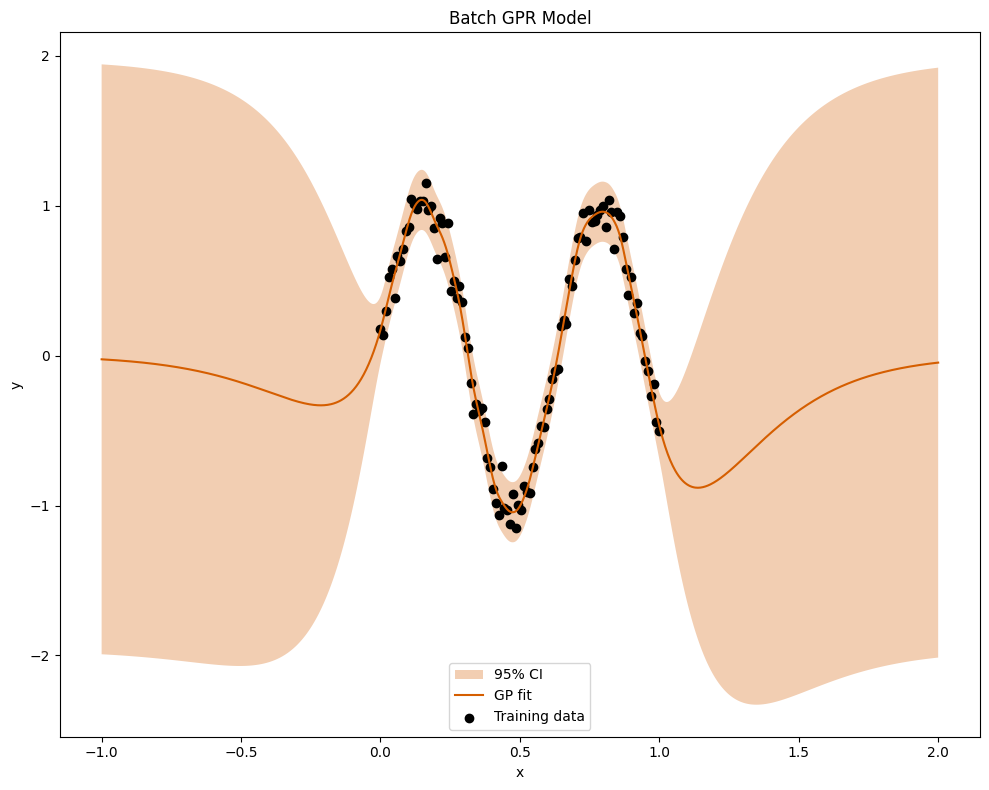

In [8]:
XS_plot = np.squeeze(XS)

plt.figure(figsize=(10, 8))
plt.title('Batch GPR Model')

plt.fill_between(
    XS_plot,
    pred_mu - 1.96 * np.sqrt(pred_var),
    pred_mu + 1.96 * np.sqrt(pred_var),
    facecolor=colors.LINE_COL,
    alpha=0.3,
    label="95% CI",
)

plt.plot(XS_plot, pred_mu, color=colors.LINE_COL, label="GP fit")
plt.scatter(np.squeeze(X), np.squeeze(Y), color="black", label="Training data")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.tight_layout()
plt.show()